# Libraries

In [1]:
import os
import matplotlib.pyplot as plt
from PIL import Image
from src.dataset import ARCADEDataset

# Data Loading

In [2]:
train_dataset = ARCADEDataset(root_dir="arcade/stenosis", split="train", image_size=(512, 512), augment=True)
val_dataset = ARCADEDataset(root_dir="arcade/stenosis", split="val", image_size=(512, 512), augment=False)
test_dataset = ARCADEDataset(root_dir="arcade/stenosis", split="test", image_size=(512, 512), augment=False)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 1000
Validation: 200
Test: 300


#  Dataset Sample Visualization

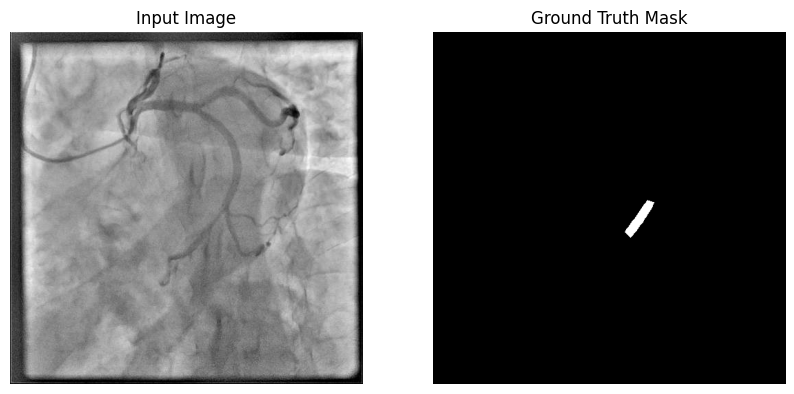

In [3]:
image, mask = train_dataset[0]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image.squeeze(), cmap="gray")
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask.squeeze(), cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.show()

#  Train

In [4]:
!python -m src.train

Device: cuda
Mixed Precision FP16: Enabled
Batch size: 8
Epochs: 50
Training samples: 1000
Validation samples: 200

--------------------------------------------------
Epoch [1/50]
--------------------------------------------------
Validation: 100%|█████| 25/25 [00:06<00:00,  4.07it/s, dice=0.0002, loss=1.4152]

Train Loss: 1.4970
Train Dice: 0.0091
Val Loss:   1.4152
Val Dice:   0.0005

Best model saved
Best Val Dice: 0.0005

--------------------------------------------------
Epoch [2/50]
--------------------------------------------------
Validation: 100%|█████| 25/25 [00:06<00:00,  4.06it/s, dice=0.0237, loss=1.3330]

Train Loss: 1.3640
Train Dice: 0.0115
Val Loss:   1.3344
Val Dice:   0.0315

Best model saved
Best Val Dice: 0.0315

--------------------------------------------------
Epoch [3/50]
--------------------------------------------------
Validation: 100%|█████| 25/25 [00:06<00:00,  4.13it/s, dice=0.0193, loss=1.2813]

Train Loss: 1.3027
Train Dice: 0.0558
Val Loss:   1.2843
Va

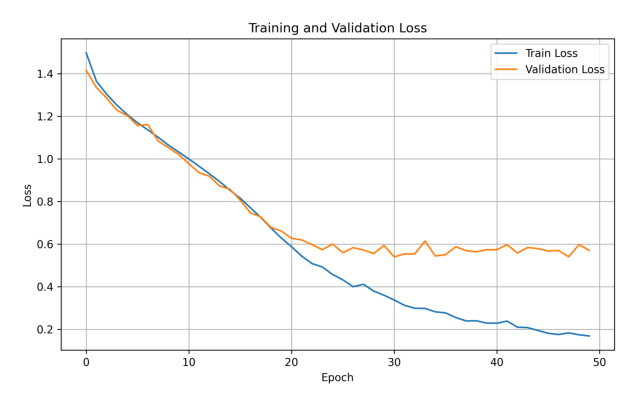

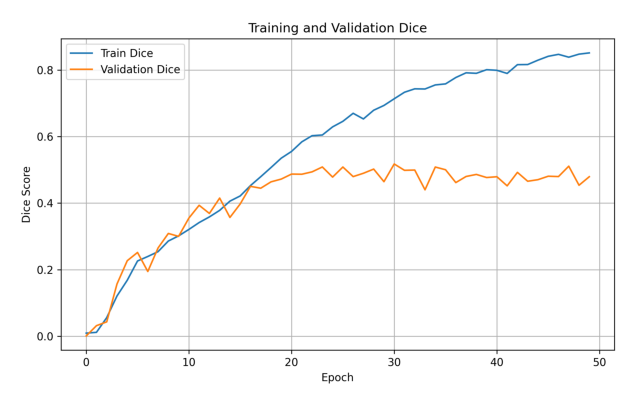

In [5]:
loss_curve = Image.open("results/loss_curve.png")
dice_curve = Image.open("results/dice_curve.png")

plt.figure(figsize=(8, 5))
plt.imshow(loss_curve)
plt.axis("off")
plt.show()

plt.figure(figsize=(8, 5))
plt.imshow(dice_curve)
plt.axis("off")
plt.show()

# Inference

In [6]:
!python -m src.inference

Device: cuda
Model: results/best_model.pth
Test samples: 300
Inference: 100%|███████████████████| 38/38 [00:15<00:00,  2.42it/s, dice=0.3881]

--------------------------------------------------
Inference completed.
--------------------------------------------------
Test Dice: 0.4810
Saved predictions: 10
Output directory: results/predictions


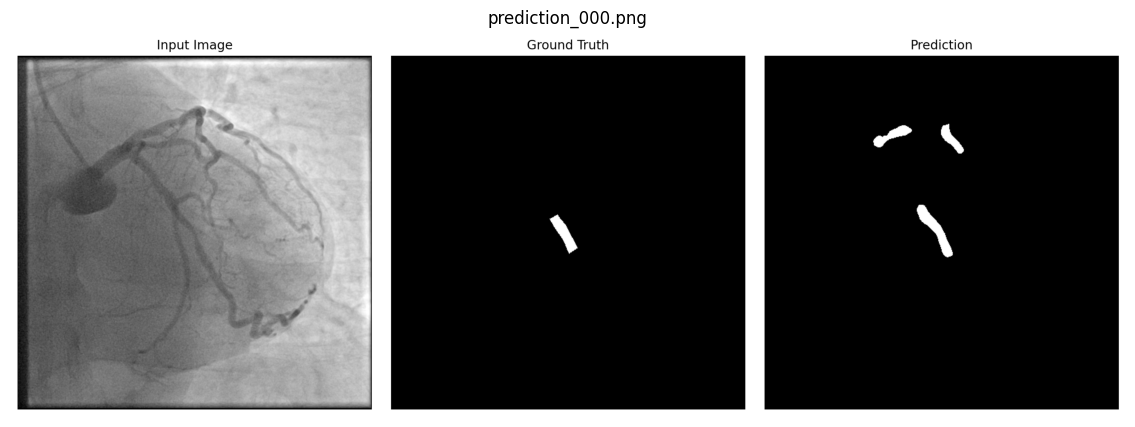

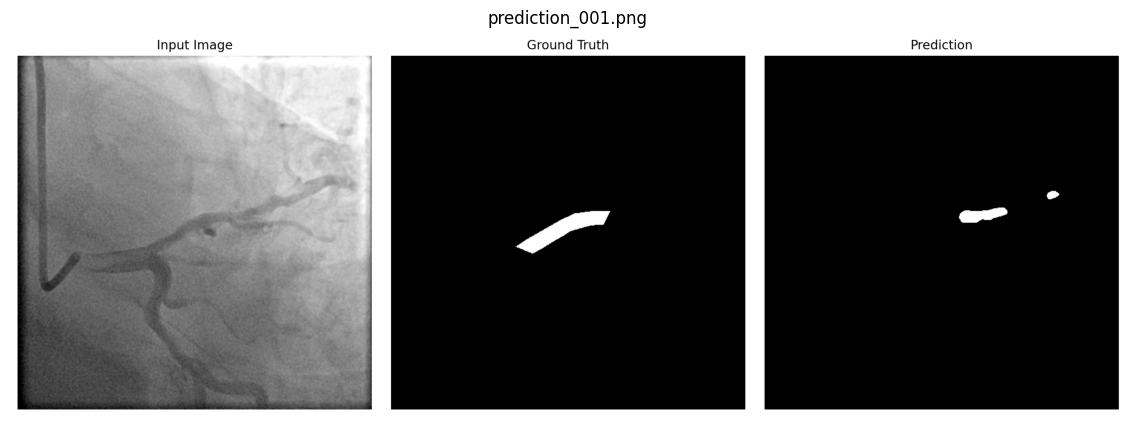

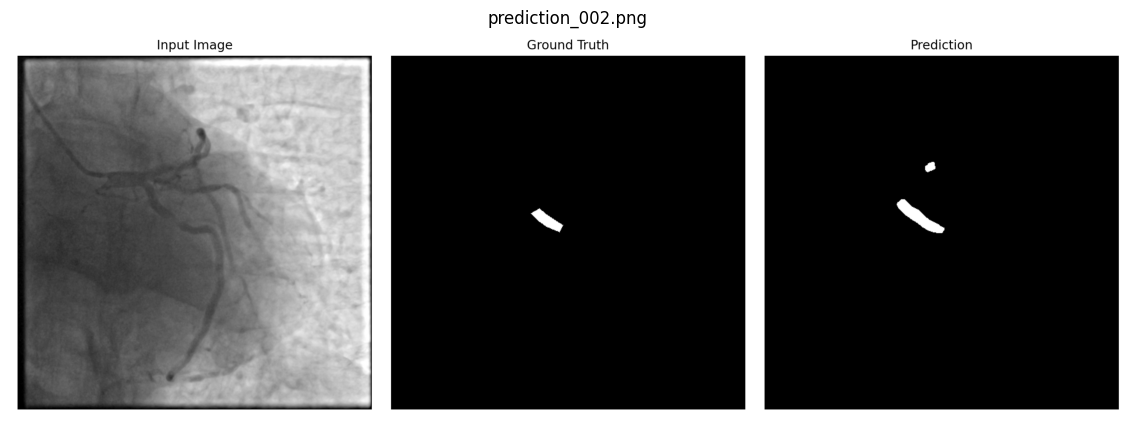

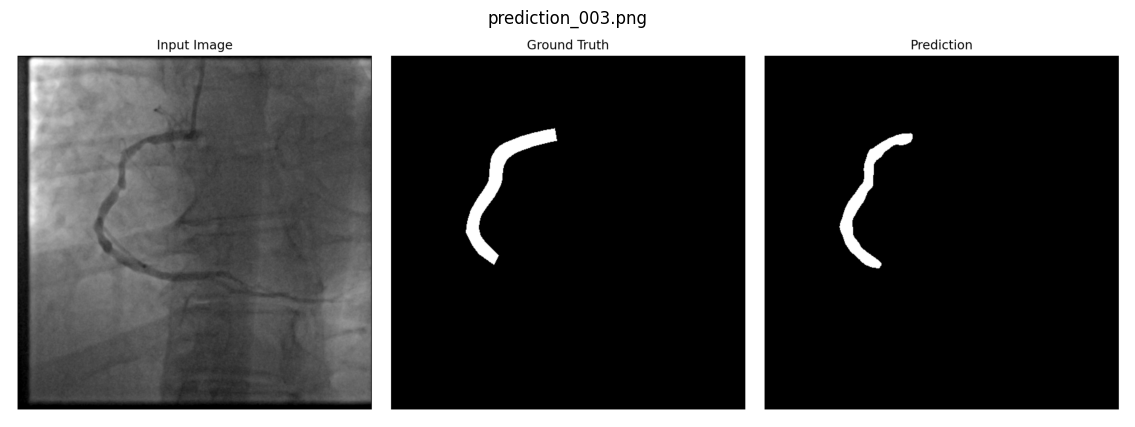

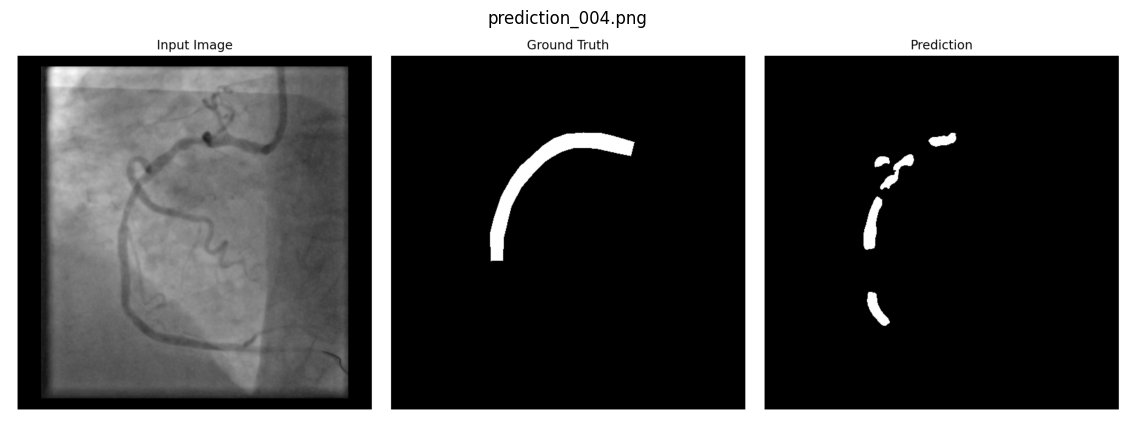

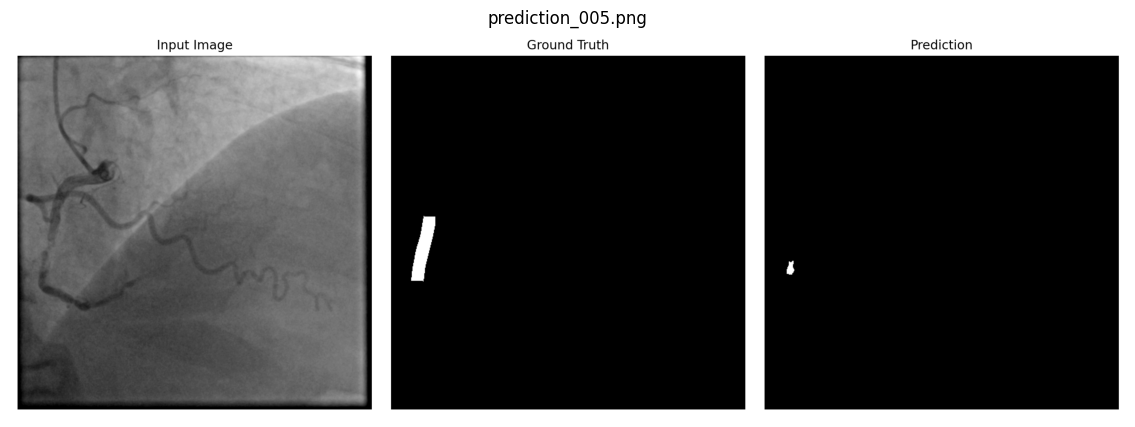

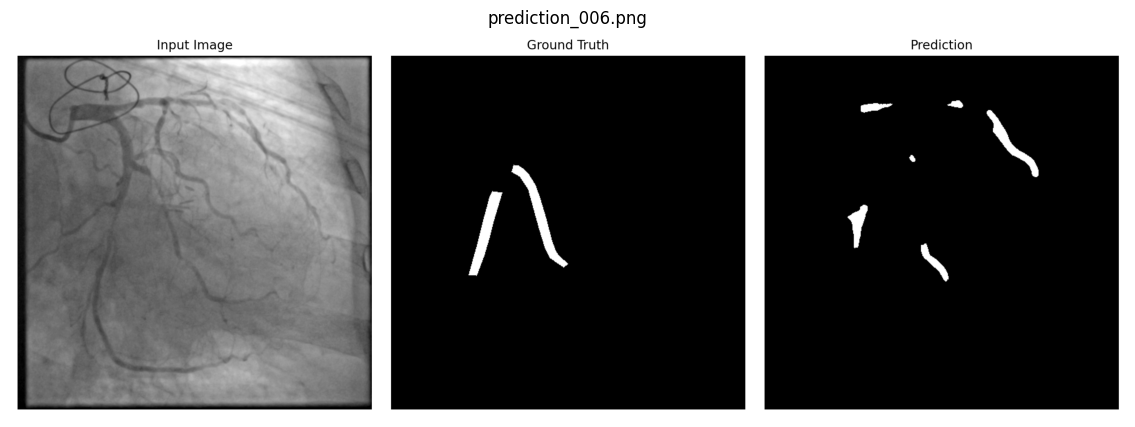

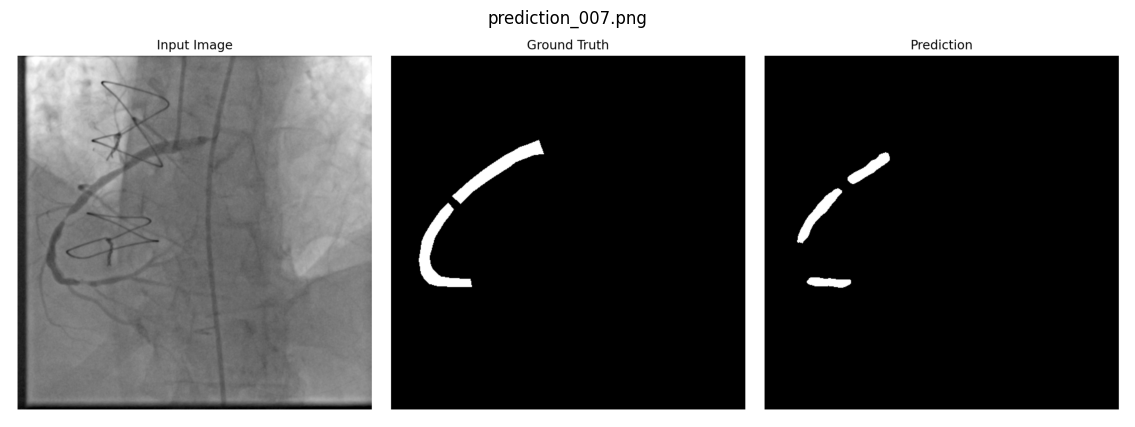

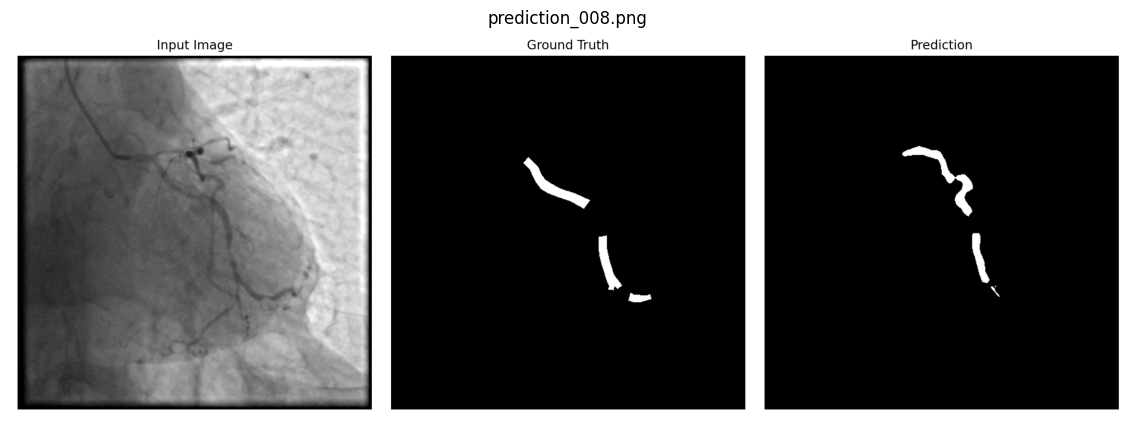

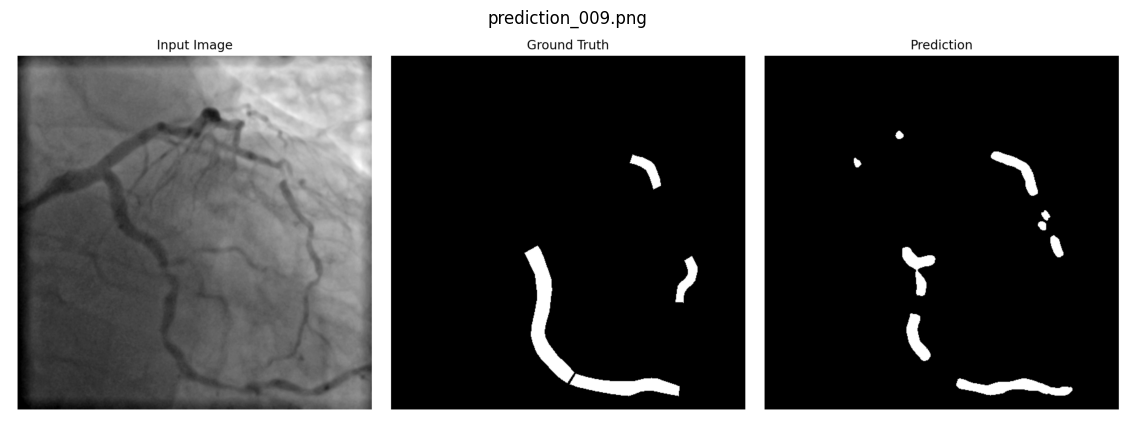

In [7]:
prediction_dir = "results/predictions"

files = sorted([
    f for f in os.listdir(prediction_dir)
    if f.endswith(".png")
])

for file in files:
    
    image = Image.open(os.path.join(prediction_dir, file))
    
    plt.figure(figsize=(15, 5))
    plt.imshow(image)
    plt.title(file)
    plt.axis("off")
    plt.show()